In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from hirank import RankOD

import time
import warnings

In [2]:
def ood_train_test_split(X, y, hold_out_label, rng=np.random.default_rng()):
    # Split into normal and ood sets
    ood_mask = y == hold_out_label

    X_inlier = X[~ood_mask]
    y_inlier = y[~ood_mask]
    X_outlier = X[ood_mask]
    y_outlier = y[ood_mask]

    inlier_test_mask = np.zeros(X_inlier.shape[0], dtype="bool")
    inlier_test_mask[rng.choice(np.arange(len(inlier_test_mask)), size=np.sum(ood_mask), replace=False)] = True

    X_train = X_inlier[~inlier_test_mask]
    y_train = y_inlier[~inlier_test_mask]
    X_test = np.vstack([X_outlier, X_inlier[inlier_test_mask]])
    y_test = np.concatenate([y_outlier, y_inlier[inlier_test_mask]])
    y_ood = y_test == hold_out_label

    split = {"x_train":X_train, "x_test":X_test, "y_test":y_test, "y_ood":y_ood, "hold_out_label":hold_out_label}
    return split

# Load MNIST Data

In [3]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# Take a subset for faster computation
n_samples = 10000
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

Loading MNIST dataset...
✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(983), 1: np.int64(1179), 2: np.int64(976), 3: np.int64(997), 4: np.int64(979), 5: np.int64(880), 6: np.int64(1017), 7: np.int64(1018), 8: np.int64(943), 9: np.int64(1028)}


In [4]:
mnist_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in mnist_splits:
    split["dataset"] = "mnist"
len(mnist_splits)

10

# Load Fashion MNIST Data

In [5]:
fashion = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X = fashion.data.to_numpy()
y = fashion.target.astype(int).to_numpy()

# Take a subset for faster computation
n_samples = 10000
indices = np.random.choice(len(X), n_samples, replace=False)
X, y = X[indices], y[indices]

# Normalize to [0, 1]
X = X / 255.0

print(f"✓ Loaded {len(X):,} samples with {X.shape[1]} features")
print(f"Class distribution: {dict(zip(range(10), np.bincount(y)))}")

✓ Loaded 10,000 samples with 784 features
Class distribution: {0: np.int64(1008), 1: np.int64(1001), 2: np.int64(1069), 3: np.int64(974), 4: np.int64(968), 5: np.int64(1014), 6: np.int64(968), 7: np.int64(1057), 8: np.int64(991), 9: np.int64(950)}


In [6]:
fashion_splits = [ood_train_test_split(X, y, i) for i in np.unique(y)]
for split in fashion_splits:
    split["dataset"] = "fashion"
len(fashion_splits)

10

# Aggregate Data

In [7]:
splits = mnist_splits + fashion_splits
len(splits)

20

# Define Methods

In [8]:
rank_local = RankOD(
    mode = "rank",
    calibration = "local",
    random_state = 42,
)

rank_global = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

rank_cos_local = RankOD(
    mode = "rank",
    calibration = "local",
    metric="cosine",
    random_state = 42,
)

rank_cos_global = RankOD(
    mode = "rank",
    calibration = "global",
    metric = "cosine",
    random_state = 42,
)

sun_global = RankOD(
    mode = "sun",
    calibration = "raw",
    random_state = 42,
)

sun_local = RankOD(
    mode = "rank",
    calibration = "global",
    random_state = 42,
)

lof = LocalOutlierFactor(
    novelty=True,
    algorithm="ball_tree",
)

iso = IsolationForest(
    random_state = 42,
)

methods = [rank_local, rank_global, rank_cos_local, rank_cos_global, sun_global, sun_local, lof, iso]
method_names = ["rank_local", "rank_global", "rank_cos_local", "rank_cos_global", "sun_global", "sun_local", "lof", "iso"]

# Run Tests

In [9]:
print(f"Testing {len(methods)} methods on {len(splits)} train/test splits.")
results = []
for split in splits:
    print(f"Testing dataset {split["dataset"]} with ood class {split["hold_out_label"]}")
    for method, method_name in zip(methods, method_names):
        print(f"\tTesting method {method}")
        result = {"dataset":split["dataset"], "method":method_name, "ood class":str(split["hold_out_label"])}
        # Warmup cache
        X = np.random.random((100, 30))
        with warnings.catch_warnings() as caught:
            warnings.simplefilter("ignore", category=UserWarning)
            method.fit(X)
        
        # Fit
        start = time.perf_counter()
        method.fit(split["x_train"])
        result["fit_seconds"] = time.perf_counter() - start
        # Predict
        start = time.perf_counter()
        scores = method.score_samples(split["x_test"])
        result["predict_seconds"] = time.perf_counter() - start

        # Evaluate
        result["auroc"] = roc_auc_score(~split["y_ood"], scores)
        results.append(result)

Testing 8 methods on 20 train/test splits.
Testing dataset mnist with ood class 0
	Testing method RankOD(calibration='local', random_state=42)
	Testing method RankOD(calibration='global', random_state=42)
	Testing method RankOD(calibration='local', metric='cosine', random_state=42)
	Testing method RankOD(calibration='global', metric='cosine', random_state=42)
	Testing method RankOD(calibration='raw', mode='sun', random_state=42)
	Testing method RankOD(calibration='global', random_state=42)
	Testing method LocalOutlierFactor(algorithm='ball_tree', novelty=True)
	Testing method IsolationForest(random_state=42)
Testing dataset mnist with ood class 1
	Testing method RankOD(calibration='local', random_state=42)
	Testing method RankOD(calibration='global', random_state=42)
	Testing method RankOD(calibration='local', metric='cosine', random_state=42)
	Testing method RankOD(calibration='global', metric='cosine', random_state=42)
	Testing method RankOD(calibration='raw', mode='sun', random_stat

In [18]:
df = pd.DataFrame(results)
df

,dataset,method,ood class,fit_seconds,predict_seconds,auroc
0,mnist,rank_local,0,1.793529,6.325918,0.796280
1,mnist,rank_global,0,1.886974,0.747206,0.928687
2,mnist,rank_cos_local,0,1.898240,2.021320,0.738553
3,mnist,rank_cos_global,0,1.940291,0.953555,0.863466
4,mnist,sun_global,0,1.727552,0.725361,0.890768
...,...,...,...,...,...,...
155,fashion,rank_cos_global,9,2.774573,0.839181,0.412529
156,fashion,sun_global,9,2.453184,0.857489,0.771433
157,fashion,sun_local,9,2.487171,1.124644,0.671982
158,fashion,lof,9,58.361891,13.738383,0.717679


In [19]:
dataset_means = df.groupby(["dataset", "method"])[["fit_seconds", "predict_seconds", "auroc"]].mean().reset_index()
dataset_means["ood class"] = "Average"
df = pd.concat([df, dataset_means])
df

,dataset,method,ood class,fit_seconds,predict_seconds,auroc
0,mnist,rank_local,0,1.793529,6.325918,0.796280
1,mnist,rank_global,0,1.886974,0.747206,0.928687
2,mnist,rank_cos_local,0,1.898240,2.021320,0.738553
3,mnist,rank_cos_global,0,1.940291,0.953555,0.863466
4,mnist,sun_global,0,1.727552,0.725361,0.890768
...,...,...,...,...,...,...
11,mnist,rank_cos_local,Average,1.961528,0.958123,0.792131
12,mnist,rank_global,Average,1.786803,0.765337,0.881820
13,mnist,rank_local,Average,1.790649,1.362027,0.790525
14,mnist,sun_global,Average,1.744649,0.792501,0.860309


In [20]:
df.to_feather("comparing_modes_results.feather")

In [21]:
# Fix so all plots share hues
hue_order = df["method"].unique().tolist()
hue_order

['rank_local',
 'rank_global',
 'rank_cos_local',
 'rank_cos_global',
 'sun_global',
 'sun_local',
 'lof',
 'iso']

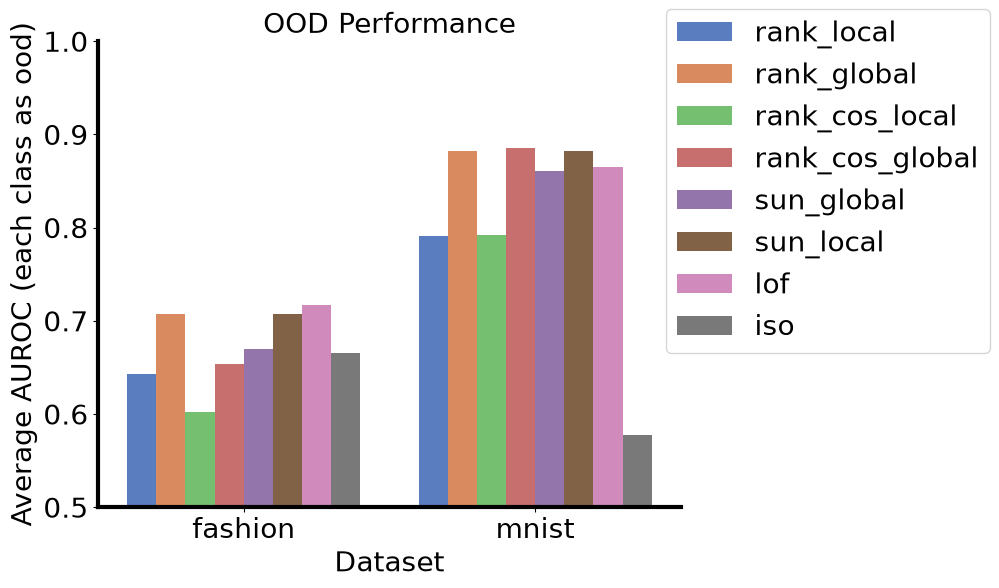

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(df[df["ood class"] == "Average"], x="dataset", y="auroc", hue="method", hue_order=hue_order, palette="muted", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance", fontsize=20)
ax.set_xlabel("Dataset", fontsize=20)
ax.set_ylabel("Average AUROC (each class as ood)", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.95, 0.7), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

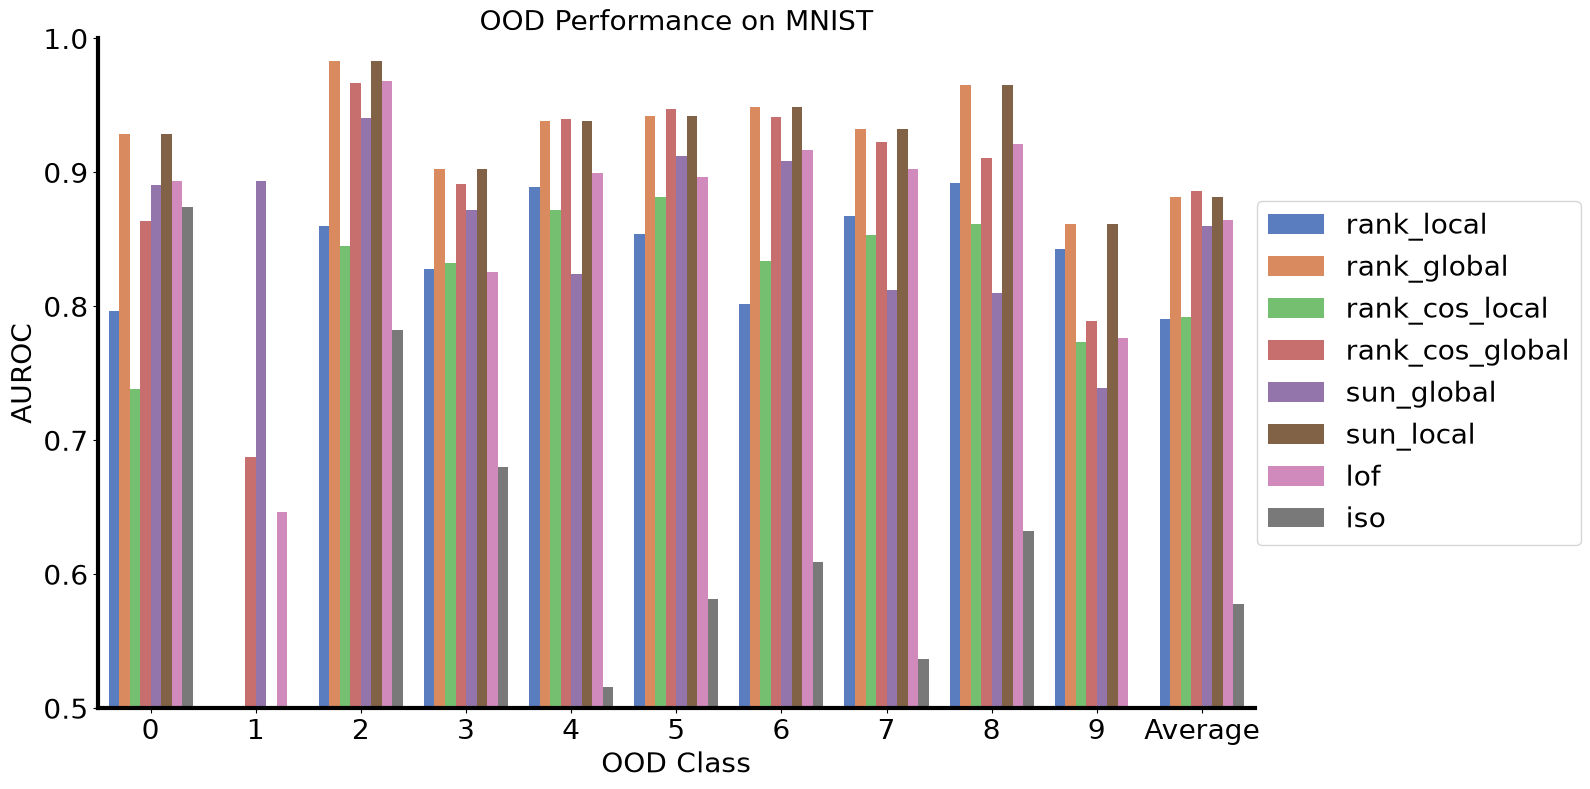

In [23]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "mnist"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="muted", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.99, 0.5), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

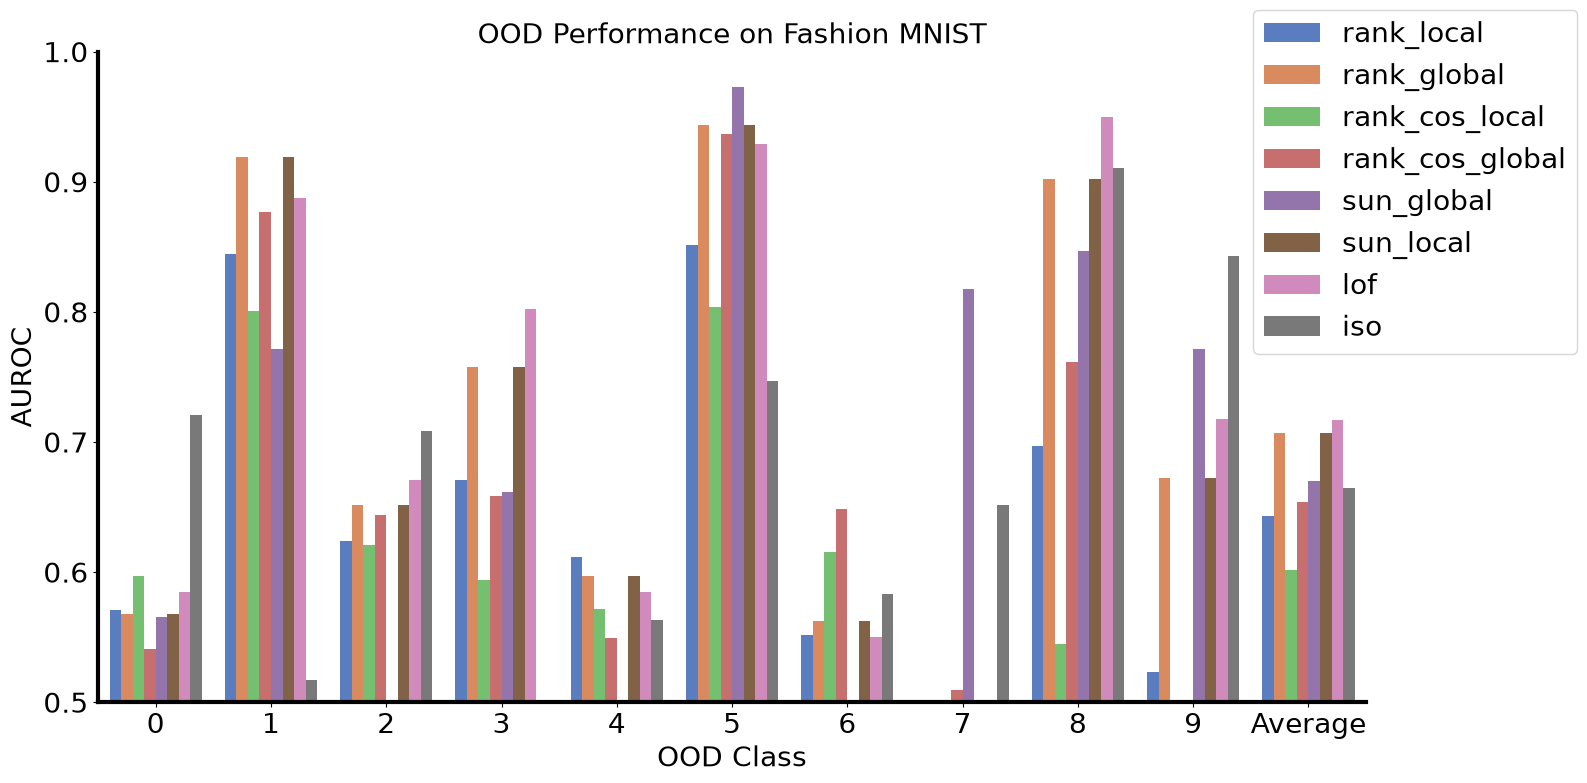

In [24]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "fashion"], x="ood class", y="auroc", hue="method", hue_order=hue_order, palette="muted", ax=ax)
ax.set_ylim((0.5, 1.))
ax.set_title("OOD Performance on Fashion MNIST", fontsize=20)
ax.set_xlabel("OOD Class", fontsize=20)
ax.set_ylabel("AUROC", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(bbox_to_anchor=(0.9, 0.8), loc="center left", fancybox=True, fontsize=20)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)
fig.tight_layout()

<Axes: xlabel='ood class', ylabel='predict_seconds'>

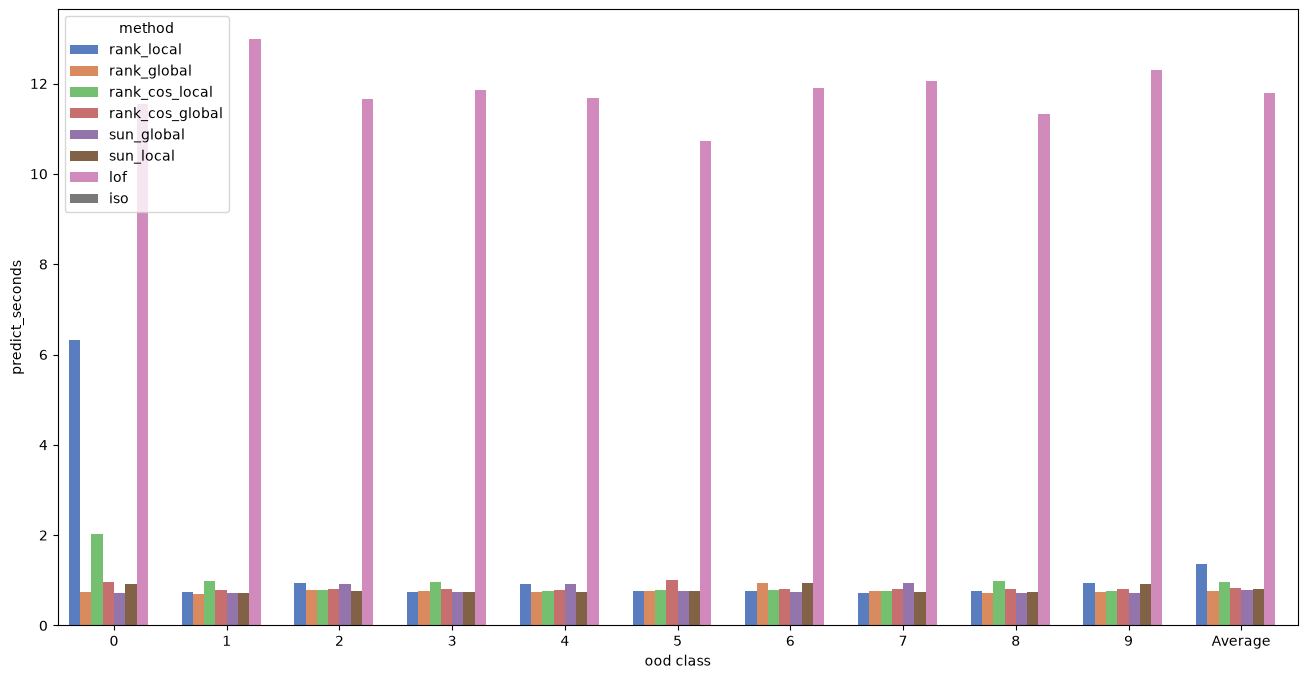

In [25]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(df[df["dataset"] == "mnist"], x="ood class", y="predict_seconds", hue="method", hue_order=hue_order, palette="muted", ax=ax)